In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **PROJECT  : House Price Prediction**

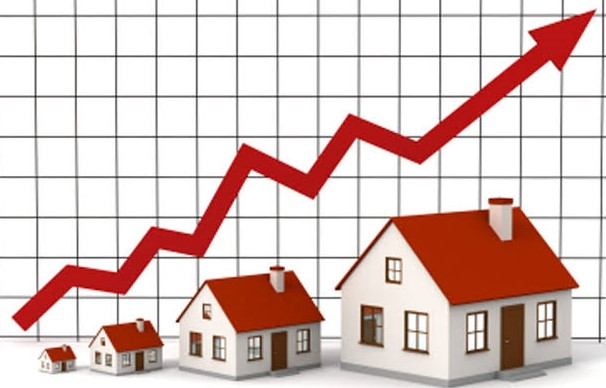

## **Phase 1 : Load Dataset**

In [2]:
data = pd.read_csv('Hyderbad_House_price.csv')
data

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction
...,...,...,...,...,...,...,...
3655,3655,2 BHK Apartment,Ameerpet,60.00,6000,1000,Ready to move
3656,3656,2 BHK Independent House,Jawahar nagar,65.00,3250,2000,Ready to move
3657,3657,2 BHK Independent Floor,Rasoolpura,65.00,6500,1000,Ready to move
3658,3658,2 BHK Independent Floor,Begum Bazar Chatri,55.00,5500,1000,Ready to move


## **Phase 2 : Understand Dataset**
*   ### Number of rows : 3660
*   ### Number of columns : 7
*   ### Missing Values : No
*   ### Duplicate rows : No
*   ### Outliers : Yes
*   ### Data Type Issues : Yes

In [3]:
data.shape

(3660, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       3660 non-null   int64  
 1   title            3660 non-null   object 
 2   location         3660 non-null   object 
 3   price(L)         3660 non-null   float64
 4   rate_persqft     3660 non-null   int64  
 5   area_insqft      3660 non-null   int64  
 6   building_status  3660 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 200.3+ KB


In [5]:
data.describe(include='all')

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
count,3660.00000,3660,3660,3660.000000,3660.000000,3660.000000,3660
unique,NaN,25,359,NaN,NaN,NaN,4
top,NaN,Residential Plot,Mirkhanpet,NaN,NaN,NaN,New
freq,NaN,1617,165,NaN,NaN,NaN,1378
mean,1829.50000,NaN,NaN,109.624350,5165.003005,2023.506284,NaN
std,1056.69532,NaN,NaN,197.596948,5316.490320,1829.832163,NaN
min,0.00000,NaN,NaN,1.320000,125.000000,118.000000,NaN
25%,914.75000,NaN,NaN,26.137500,1555.000000,1280.000000,NaN
50%,1829.50000,NaN,NaN,61.130000,4703.000000,1620.000000,NaN
75%,2744.25000,NaN,NaN,116.000000,6800.000000,2080.000000,NaN


In [6]:
data.isnull().sum()

,0
Unnamed: 0,0
title,0
location,0
price(L),0
rate_persqft,0
area_insqft,0
building_status,0


In [7]:
data.duplicated().sum()

np.int64(0)

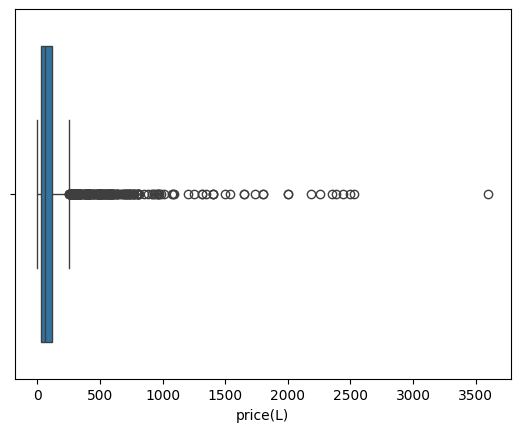

In [8]:
sns.boxplot(data=data,x='price(L)')
plt.show()

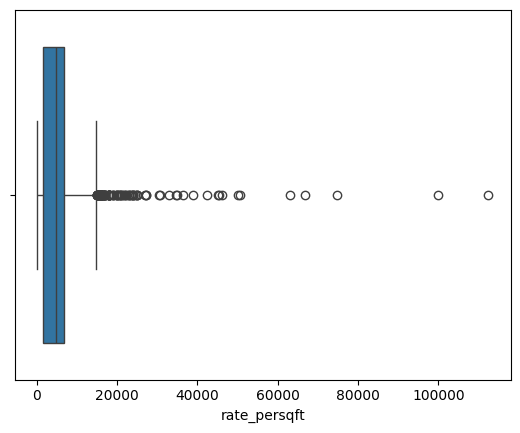

In [9]:
sns.boxplot(data=data,x='rate_persqft')
plt.show()

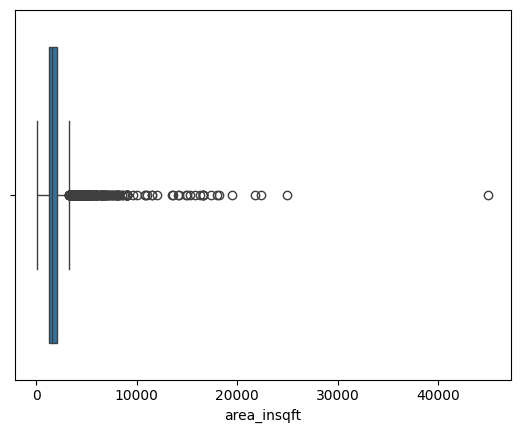

In [10]:
sns.boxplot(data=data,x='area_insqft')
plt.show()

## **Phase 3 : Exploratory Data Analysis**

### 1. The dataset is dominated by Residential Plots, 3 BHK Apartments, and 2 BHK Apartments, while villas, independent houses, and 5 BHK properties constitute only a small portion of the listings.
### 2. The average property price increases with the number of BHKs, Villas and Independent Houses are generally more expensive than Apartments, with luxury properties (5+ BHK) commanding significantly higher prices.<br><br>

### 3. Mirkhanpet, Ameenpur, and Kondapur have the highest number of property listings in the dataset, indicating they are the most represented locations among the top 10 areas.
### 4. Location has a significant impact on property prices, with premium areas such as Jubilee Hills, Kokapet, and Nanakramguda exhibiting substantially higher average property prices than locations such as Sadashivpet, Kolanupaka, and Narayan Kher.<br><br>


### 5. Property prices in the dataset range from approximately ₹1 Lakh to ₹36 Crores, indicating a wide variation in property values across different property types and locations.<br><br>

### 6. Most properties have a rate per square foot below ₹15,000, while a few premium properties with exceptionally high rates create a positively skewed distribution.
### 7. Rate per square foot has a moderately strong positive correlation (0.63) with property price, indicating that properties with higher rates per square foot generally tend to have higher overall prices.<br><br>

### 8. Most properties have a area in sqaure feet below 10,000, while a few  properties range upto 25000 area in sqft which create a positively skewed distribution.
### 9. Area in square feet has a moderate positive correlation (0.51) with property price, indicating that properties with higher area per square foot generally tend to have higher overall prices.<br><br>

### 10. The dataset is primarily composed of New (1,378) and Under Construction (1,161) properties, while Resale properties (239) represent only a small portion of the listings.
### 11. Property prices generally increase from New to Ready-to-Move properties, indicating that building status is an important factor influencing house prices.






In [11]:
data.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


### 1) Distribution of Property type

In [12]:
data['title'].value_counts()

,count
title,
Residential Plot,1617
3 BHK Apartment,798
2 BHK Apartment,667
4 BHK Apartment,114
2 BHK Independent House,101
4 BHK Villa,94
3 BHK Villa,82
4 BHK Independent House,44
3 BHK Independent House,25


### 2) Does Property type affect Price ?

In [13]:
data.groupby('title')['price(L)'].mean().sort_values()

,price(L)
title,
1 RK Studio Apartment,31.323333
1 BHK Apartment,35.328000
Residential Plot,42.393575
1 BHK Independent House,57.000000
2 BHK Independent Floor,66.619048
2 BHK Apartment,68.597091
2 BHK Villa,85.333333
3 BHK Apartment,123.845251
2 BHK Independent House,139.707624


### 3) Distribution of location

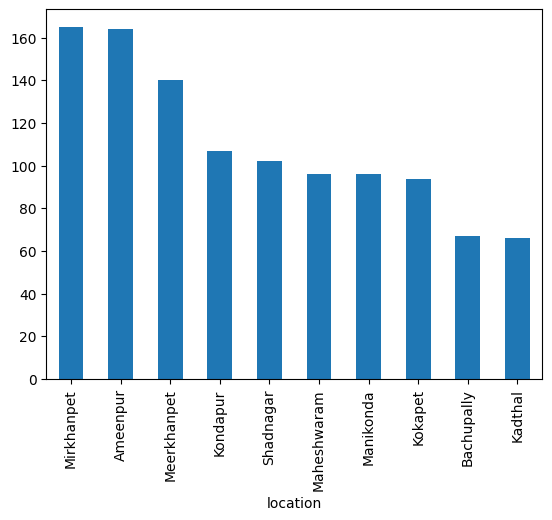

In [14]:
data['location'].value_counts().head(10).plot(kind='bar')
plt.show()

### 4) Does location affect the Price ?

In [15]:
data.groupby(['location','title'])['price(L)'].mean().sort_values(ascending=False)

,,price(L)
location,title,
Jubilee Hills,6 BHK Villa,3600.000000
Kokapet,5 BHK Apartment,2454.333333
Nanakramguda,4 BHK Villa,2350.000000
Jubilee Hills,4 BHK Independent House,2000.000000
Khajiguda,5 BHK Apartment,1991.333333
...,...,...
Hyderabad Warangal Hwy,Residential Plot,7.000000
Batasingaram,Residential Plot,6.410000
Kolanupaka,Residential Plot,6.075000


### 5) Distribution of property price

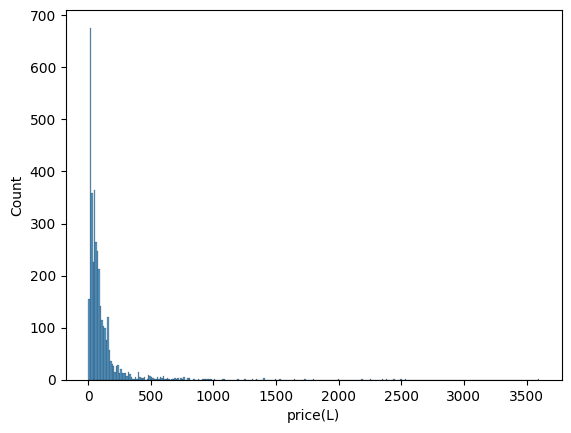

In [16]:
sns.histplot(data=data,x='price(L)')
plt.show()

### 6) Distribution of rate per square feet

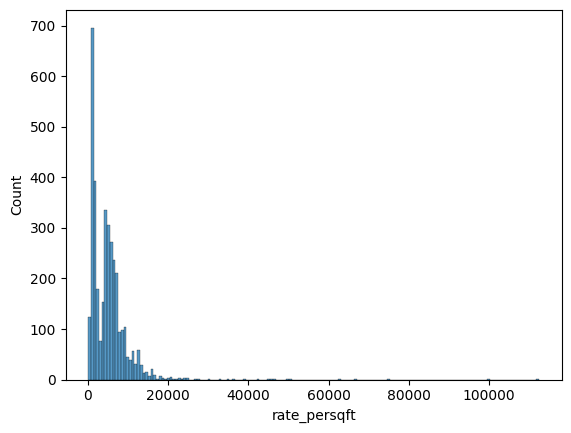

In [17]:
sns.histplot(data=data,x='rate_persqft')
plt.show()

### 7) Does rate per sqft affect price of the property ?

In [18]:
data[['rate_persqft','price(L)']].corr()

,rate_persqft,price(L)
rate_persqft,1.000000,0.628859
price(L),0.628859,1.000000


### 8) Distribution of area in square feet

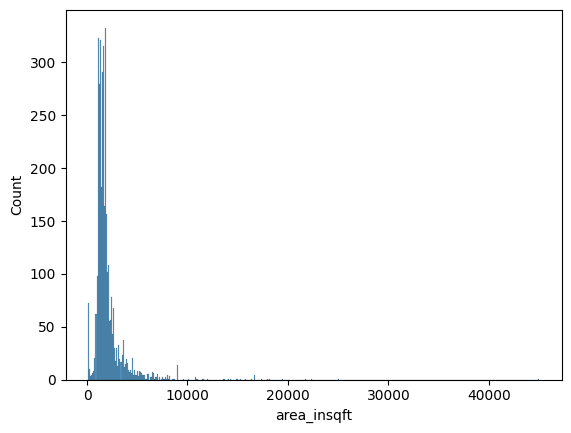

In [19]:
sns.histplot(data=data,x='area_insqft')
plt.show()

### 9) Does area in sqft affect price of the property?

In [20]:
data[['area_insqft','price(L)']].corr()

,area_insqft,price(L)
area_insqft,1.000000,0.516428
price(L),0.516428,1.000000


### 10) Distribution of building status ?

In [21]:
data['building_status'].value_counts()

,count
building_status,
New,1378
Under Construction,1161
Ready to move,882
Resale,239


### 11) How building status related to price ?

In [22]:
data.groupby('building_status')['price(L)'].mean().sort_values()

,price(L)
building_status,
New,36.067743
Resale,78.866360
Under Construction,158.252506
Ready to move,168.870238


### 12) Heatmap of all numeric columns in dataset

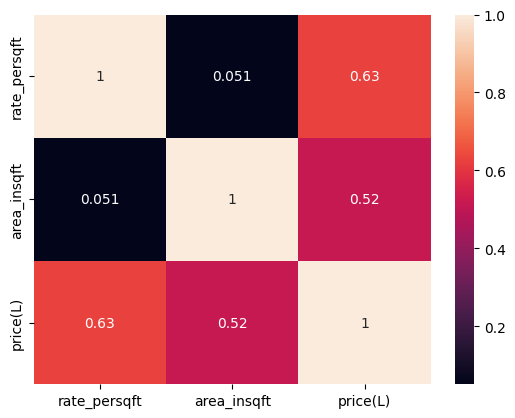

In [23]:
corr = data[['rate_persqft','area_insqft','price(L)']].corr()
sns.heatmap(corr,annot=True)
plt.show()

## **Phase 4 : Data Cleaning**

In [24]:
data.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


### location feature -- Text Standardization

In [25]:
data['location'].nunique()

359

In [26]:
data['location'] = data['location'].str.strip().str.title()

In [27]:
data['location'].nunique()

358

### Outliers do exist ( in columns : price, rate persft, area insqft ) :  but they look like natural, genuine variations - so keeping it untouched

In [28]:
data = data.drop(columns=['Unnamed: 0'])
data.head()

,title,location,price(L),rate_persqft,area_insqft,building_status
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


## **Phase 5 : Feature Engineering**

In [29]:
data.head()

,title,location,price(L),rate_persqft,area_insqft,building_status
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [30]:
data.shape

(3660, 6)

In [31]:
data = pd.get_dummies(
    data,
    columns=['title','location','building_status'],
    dtype=int
)
data.head()

,price(L),rate_persqft,area_insqft,title_1 BHK Apartment,title_1 BHK Independent House,title_1 RK Studio Apartment,title_10 BHK Independent House,title_2 BHK Apartment,title_2 BHK Independent Floor,title_2 BHK Independent House,...,location_Yacharam Mandal,location_Yadadri Colony Road,location_Yadagirigutta,location_Yapral,location_Yousufguda,location_Zaheerabad,building_status_New,building_status_Ready to move,building_status_Resale,building_status_Under Construction
0,108.00,6000,1805,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,85.80,5500,1560,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,55.64,5200,1070,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,60.48,4999,1210,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,113.00,5999,1900,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [32]:
data.shape

(3660, 390)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Columns: 390 entries, price(L) to building_status_Under Construction
dtypes: float64(1), int64(389)
memory usage: 10.9 MB


## **Phase 6 : Train - Test Split**

In [34]:
data.head()

,price(L),rate_persqft,area_insqft,title_1 BHK Apartment,title_1 BHK Independent House,title_1 RK Studio Apartment,title_10 BHK Independent House,title_2 BHK Apartment,title_2 BHK Independent Floor,title_2 BHK Independent House,...,location_Yacharam Mandal,location_Yadadri Colony Road,location_Yadagirigutta,location_Yapral,location_Yousufguda,location_Zaheerabad,building_status_New,building_status_Ready to move,building_status_Resale,building_status_Under Construction
0,108.00,6000,1805,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,85.80,5500,1560,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,55.64,5200,1070,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,60.48,4999,1210,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,113.00,5999,1900,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [35]:
x = data.drop(columns=['price(L)'])
x.head()

,rate_persqft,area_insqft,title_1 BHK Apartment,title_1 BHK Independent House,title_1 RK Studio Apartment,title_10 BHK Independent House,title_2 BHK Apartment,title_2 BHK Independent Floor,title_2 BHK Independent House,title_2 BHK Villa,...,location_Yacharam Mandal,location_Yadadri Colony Road,location_Yadagirigutta,location_Yapral,location_Yousufguda,location_Zaheerabad,building_status_New,building_status_Ready to move,building_status_Resale,building_status_Under Construction
0,6000,1805,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,5500,1560,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,5200,1070,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4999,1210,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5999,1900,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [36]:
y = data['price(L)']
y.head()

,price(L)
0,108.00
1,85.80
2,55.64
3,60.48
4,113.00


In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
# print("training set of x :",x_train)
# print("training set of y :",y_train)
# print("testing set of x :",x_test)
# print("testing set of y :",x_test)

## **Phase 7 : Baseline model**

### Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression
modelLR = LinearRegression()
modelLR.fit(x_train,y_train)
predictionLR = modelLR.predict(x_test)

In [39]:
# result of linear regression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionLR)
mse = mean_squared_error(y_test,predictionLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionLR)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelLR.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 36.91578884544107
mean squared error : 8459.287569137927
root mean squared error : 91.97438539690236
train_r2 score 0.8722405907741781
test_r2 score : 0.7771995325008847


### Decision Tree

In [40]:
from sklearn.tree import DecisionTreeRegressor
modelDT = DecisionTreeRegressor()
modelDT.fit(x_train,y_train)
predictionDT = modelDT.predict(x_test)

In [41]:
# result of Decision Tree
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionDT)
mse = mean_squared_error(y_test,predictionDT)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionDT)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelDT.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 7.963283242258653
mean squared error : 1910.1356892304188
root mean squared error : 43.70509912161759
train_r2 score 0.9999999913017351
test_r2 score : 0.9496909023284744


### Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor
modelRF = RandomForestRegressor()
modelRF.fit(x_train,y_train)
predictionRF = modelRF.predict(x_test)

In [43]:
# result of random forest
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionRF)
mse = mean_squared_error(y_test,predictionRF)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionRF)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelRF.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 6.554815089285717
mean squared error : 2219.1326434450884
root mean squared error : 47.107670749519
train_r2 score 0.9930013985163354
test_r2 score : 0.9415525496253464


### K-Nearest Neighbors

In [44]:
from sklearn.neighbors import KNeighborsRegressor
modelKNN = KNeighborsRegressor()
modelKNN.fit(x_train,y_train)
predictionKNN = modelKNN.predict(x_test)

In [45]:
# result of knn
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionKNN)
mse = mean_squared_error(y_test,predictionKNN)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionKNN)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelKNN.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 10.932125683060107
mean squared error : 6724.5996411147535
root mean squared error : 82.00365626674675
train_r2 score 0.9221686970960796
test_r2 score : 0.8228876921916211


### Support Vector Machine SVM

In [46]:
from sklearn.svm import SVR
modelSVM = SVR()
modelSVM.fit(x_train,y_train)
predictionSVM = modelSVM.predict(x_test)

In [47]:
# result of svm
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionSVM)
mse = mean_squared_error(y_test,predictionSVM)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionSVM)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelSVM.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 43.5828687547081
mean squared error : 28992.63601045576
root mean squared error : 170.27224086872104
train_r2 score 0.20870267175960444
test_r2 score : 0.23639280443335076


### XG BOOST

In [48]:
from xgboost import XGBRegressor
modelXG = XGBRegressor()
modelXG.fit(x_train,y_train)
predictionXG = modelXG.predict(x_test)

In [49]:
# result of xgboost
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionXG)
mse = mean_squared_error(y_test,predictionXG)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionXG)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelXG.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 8.092906408726844
mean squared error : 1798.9965107955688
root mean squared error : 42.41457898878131
train_r2 score 0.999750995846745
test_r2 score : 0.9526180827453089


### Voting

In [50]:
from sklearn.ensemble import VotingRegressor
modelV = VotingRegressor(estimators=[
    ('lr',LinearRegression()),
    ('dt',DecisionTreeRegressor()),
    ('rf',RandomForestRegressor()),
    ('knn',KNeighborsRegressor()),
    ('svm',SVR()),
    ('xgb',XGBRegressor())
])
modelV.fit(x_train,y_train)
predictionV = modelV.predict(x_test)

In [51]:
# result of voting
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionV)
mse = mean_squared_error(y_test,predictionV)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionV)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelV.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 14.506994977608876
mean squared error : 4171.184026016732
root mean squared error : 64.58470427289059
train_r2 score 0.9508586553272679
test_r2 score : 0.8901394776538992


### stacking

In [52]:
from sklearn.ensemble import StackingRegressor
modelS = StackingRegressor(
    estimators=[
    ('lr',LinearRegression()),
    ('dt',DecisionTreeRegressor()),
    ('rf',RandomForestRegressor()),
    ('knn',KNeighborsRegressor()),
    ('svm',SVR()),
    ('xgb',XGBRegressor())
    ], final_estimator = DecisionTreeRegressor() )
modelS.fit(x_train,y_train)
predictionS = modelS.predict(x_test)

In [53]:
# result of stacking
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionS)
mse = mean_squared_error(y_test,predictionS)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionS)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelS.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 8.402021857923499
mean squared error : 3364.7168937158476
root mean squared error : 58.00617978901772
train_r2 score 0.9610703356315407
test_r2 score : 0.9113801852939658


## **Phase 8 : Comparision of baseline models -- selecting top best models**

| Model | Train R² | Test R² | MAE | RMSE |
|--------|--------|--------|--------|--------|
| Linear Regression | 0.87 | 0.77 | 36.9 | 91.97 |
| Decision Tree | 0.99 | 0.94 | 8.03 | 43.81 |
| Random Forest | 0.99 | 0.93 | 6.52 | 47.77 |
| KNN | 0.92 | 0.82 | 10.93 | 82.00 |
| SVM | 0.20 | 0.23 | 43.58 | 170.27 |
| XGBoost | 0.99 | 0.95 | 8.09 | 42.41 |
| Voting | 0.95 | 0.89 | 14.50 | 64.60 |
| Stacking | 0.97 | 0.97 | 8.15 | 52.01 |

### Based on the model evaluation results, the top three performing models ( XGBoost, Decision Tree) were selected for hyperparameter tuning.

## **Phase 9 : Tuned Model -- Hyper parameter tuning**

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

### XGBoost

In [62]:
params_xg = {
    'n_estimators':[100,200,300,400,500],
    'max_depth': list(range(1,390))+[None],
    'learning_rate':[0.01,0.1,0.2]
}
random = RandomizedSearchCV(estimator=XGBRegressor(),param_distributions=params_xg,n_iter=10,cv=5)
random.fit(x_train,y_train)
print(random.best_params_)
print(random.best_score_)

{'n_estimators': 400, 'max_depth': 309, 'learning_rate': 0.01}
0.9300916180226284


In [63]:
modelXGT = XGBRegressor(n_estimators=random.best_params_['n_estimators'],max_depth=random.best_params_['max_depth'],learning_rate=random.best_params_['learning_rate'])
modelXGT.fit(x_train,y_train)
predictionXGT = modelXGT.predict(x_test)

In [64]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionXGT)
mse = mean_squared_error(y_test,predictionXGT)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionXGT)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelXGT.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 8.049502167571438
mean squared error : 2014.1282152447457
root mean squared error : 44.87903982088683
train_r2 score 0.9963383847529946
test_r2 score : 0.9469519502331543


### Decision Tree

In [65]:
params_dt = {
    'max_depth': list(range(1,390))+[None]
}
grid = GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=params_dt,cv=5)
grid.fit(x_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 110}
0.9217598844640225


In [66]:
modelDTT = DecisionTreeRegressor(max_depth=grid.best_params_['max_depth'])
modelDTT.fit(x_train,y_train)
predictionDTT = modelDTT.predict(x_test)

In [67]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test,predictionDTT)
mse = mean_squared_error(y_test,predictionDTT)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictionDTT)
print("mean average error :",mae)
print("mean squared error :",mse)
print("root mean squared error :",rmse)
print("train_r2 score",modelDTT.score(x_train,y_train))
print("test_r2 score :",r2)

mean average error : 7.9412477231329675
mean squared error : 1978.4782280965392
root mean squared error : 44.480087995602474
train_r2 score 0.9999999913017351
test_r2 score : 0.9478908985474231


## **Phase 10 : Insights & Conclusion**

### After evaluating multiple machine learning models and performing hyperparameter tuning, the **tuned Decision Tree Regressor** achieved the best overall performance and was selected as the final model for house price prediction.

In [69]:
import joblib
joblib.dump(modelDTT,'House_price_prediction_model.pkl')

['House_price_prediction_model.pkl']

## **Insights**
### 1. The dataset is heavily dominated by Residential Plots and Apartment-type properties, indicating that these property categories constitute the majority of the Hyderabad real estate market represented in the dataset.
### 2. The number of BHKs has a direct impact on property prices, with higher-BHK properties generally commanding higher prices.
### 3. Villas and Independent Houses are significantly more expensive than Apartments, reflecting the premium associated with larger living spaces and independent ownership.
### 4. roperty location is one of the strongest determinants of price. Premium locations such as Jubilee Hills, Kokapet, and Nanakramguda exhibit substantially higher average prices compared to developing or suburban areas.
### 5. The dataset contains a wide range of property values, from affordable properties to luxury real estate worth several crores, indicating a diverse housing market.
### 6. Rate per square foot shows a strong positive relationship with property price, making it one of the most influential features for price prediction.
### 7. Property area also contributes significantly to price, as larger properties generally tend to have higher market values.
### 8. The distributions of both area and rate per square foot are positively skewed due to the presence of a small number of premium properties.
### 9. Most listed properties are either New or Under Construction, suggesting a strong focus on newly developed residential projects in the market.
### 10. Building status influences property valuation, with Ready-to-Move properties generally attracting higher prices than properties under construction.<br></br>

## **Conclusion**

### 1. This project analyzed Hyderabad housing data through data cleaning, exploratory data analysis, feature engineering, and machine learning techniques to understand the factors affecting property prices.

### 2. EDA revealed that location, property type, BHK count, area, rate per square foot, and building status are key factors influencing house prices. Premium locations and larger properties consistently exhibited higher market values. Additionally, rate per square foot and area demonstrated strong positive relationships with property price.

### 3. Multiple machine learning models were trained and evaluated, and after hyperparameter tuning, the Decision Tree Regressor achieved the best overall performance and was selected as the final model. The developed model can effectively estimate property prices based on the available property characteristics and can support data-driven real estate decision-making.

### 4. This project demonstrates how machine learning can be applied to real-world housing data to generate meaningful insights and accurate price predictions.